In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("6G_NearField_Dataset.csv")

print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])
print("\nSütun isimleri:")
print(df.columns.tolist())
df.head()

Satır sayısı: 200000
Sütun sayısı: 31

Sütun isimleri:
['Sample_ID', 'Dist_True', 'Angle_True', 'SNR_dB', 'Rayleigh_Dist', 'CSI_Real_Mid', 'CSI_Imag_Mid', 'Phase_Slope', 'Is_Near_Field', 'Path_Loss', 'Timestamp', 'Random_Col_1', 'Random_Col_2', 'Random_Col_3', 'Random_Col_4', 'Random_Col_5', 'Random_Col_6', 'Random_Col_7', 'Random_Col_8', 'Random_Col_9', 'Random_Col_10', 'Random_Col_11', 'Random_Col_12', 'Random_Col_13', 'Random_Col_14', 'Random_Col_15', 'Random_Col_16', 'Random_Col_17', 'Random_Col_18', 'Random_Col_19', 'Random_Col_20']


,Sample_ID,Dist_True,Angle_True,SNR_dB,Rayleigh_Dist,CSI_Real_Mid,CSI_Imag_Mid,Phase_Slope,Is_Near_Field,Path_Loss,...,Random_Col_11,Random_Col_12,Random_Col_13,Random_Col_14,Random_Col_15,Random_Col_16,Random_Col_17,Random_Col_18,Random_Col_19,Random_Col_20
0,0,48.036449,1.099694,24,32.768,0.205425,0.985389,-2.503433,0,115.615615,...,31.752865,66.801427,32.483425,92.442386,37.857042,39.184132,24.450394,93.502307,76.285021,72.010826
1,1,49.585810,0.059456,27,32.768,0.977963,0.067562,-2.760816,0,115.891345,...,5.388551,53.923718,86.226976,72.715988,62.353880,92.564585,57.438131,49.775139,44.474613,63.739803
2,2,41.694039,-0.536080,29,32.768,0.685180,-0.689752,5.472280,0,114.385677,...,52.183249,99.056717,67.858736,76.672217,77.379290,48.728571,18.535584,66.180758,95.146232,22.473323
3,3,36.944816,-0.465565,24,32.768,0.718051,-0.643388,4.798593,0,113.335267,...,0.422003,31.794527,56.759931,93.549627,55.876883,44.412210,8.272321,1.037393,42.439405,30.197280
4,4,39.797659,-0.516685,4,32.768,0.995009,-0.705125,0.293777,0,113.981348,...,10.933412,18.823691,90.077995,69.831822,41.911791,88.848050,26.017939,60.486434,24.555824,95.016484


In [3]:
# Gereksiz sütunların temizlenmesi kısmı:
random_cols = [f"Random_Col_{i}" for i in range(1, 21)]
drop_cols = ["Sample_ID", "Timestamp", "Rayleigh_Dist"] + random_cols

df_clean = df.drop(columns=drop_cols)

print("Temizlenen veri seti boyutu:", df_clean.shape)
print("\nKalan sütunlar:", df_clean.columns.tolist())
print("\nTemel istatistikler:")
df_clean.describe().round(3)

Temizlenen veri seti boyutu: (200000, 8)

Kalan sütunlar: ['Dist_True', 'Angle_True', 'SNR_dB', 'CSI_Real_Mid', 'CSI_Imag_Mid', 'Phase_Slope', 'Is_Near_Field', 'Path_Loss']

Temel istatistikler:


,Dist_True,Angle_True,SNR_dB,CSI_Real_Mid,CSI_Imag_Mid,Phase_Slope,Is_Near_Field,Path_Loss
count,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000
mean,25.277,0.001,14.990,0.473,0.001,0.009,0.650,107.676
std,14.308,0.907,8.935,0.451,0.854,3.126,0.477,7.728
min,0.501,-1.571,0.000,-2.562,-3.104,-6.270,0.000,75.979
25%,12.912,-0.785,7.000,0.120,-0.844,-2.513,0.000,104.204
50%,25.291,0.000,15.000,0.453,-0.000,0.010,1.000,110.044
75%,37.696,0.788,23.000,0.830,0.848,2.533,1.000,113.510
max,50.000,1.571,30.000,3.371,3.418,6.278,1.000,115.964


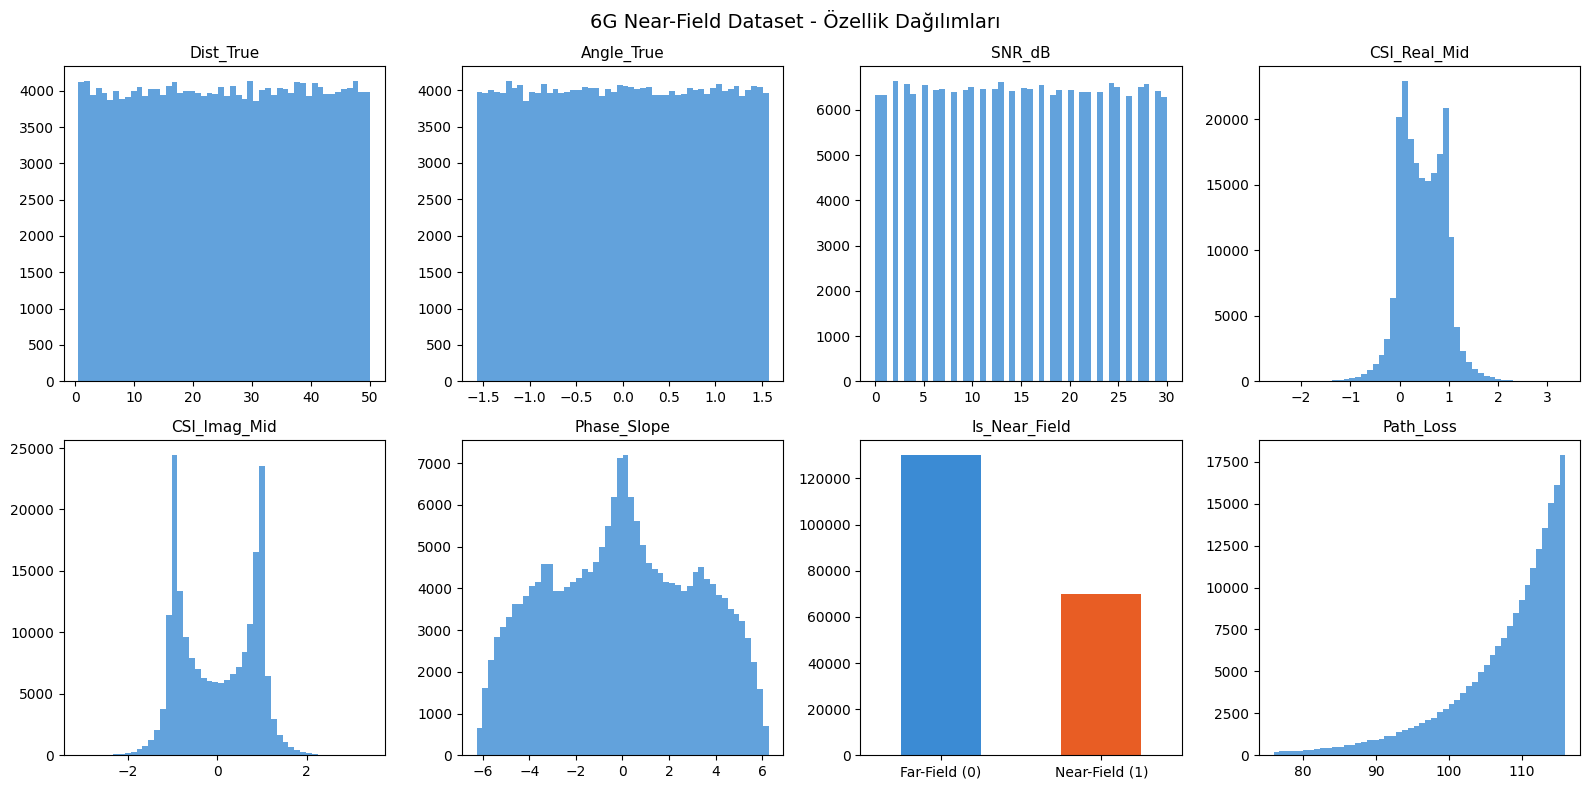

Grafik kaydedildi.


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("6G Near-Field Dataset - Özellik Dağılımları", fontsize=14)

cols = df_clean.columns.tolist()

for i, col in enumerate(cols):
    ax = axes[i // 4][i % 4]
    if col == "Is_Near_Field":
        df_clean[col].value_counts().plot(kind="bar", ax=ax, color=["#3B8BD4", "#E85D24"])
        ax.set_xticklabels(["Far-Field (0)", "Near-Field (1)"], rotation=0)
    else:
        ax.hist(df_clean[col], bins=50, color="#3B8BD4", edgecolor="none", alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150)
plt.show()
print("Grafik kaydedildi.")

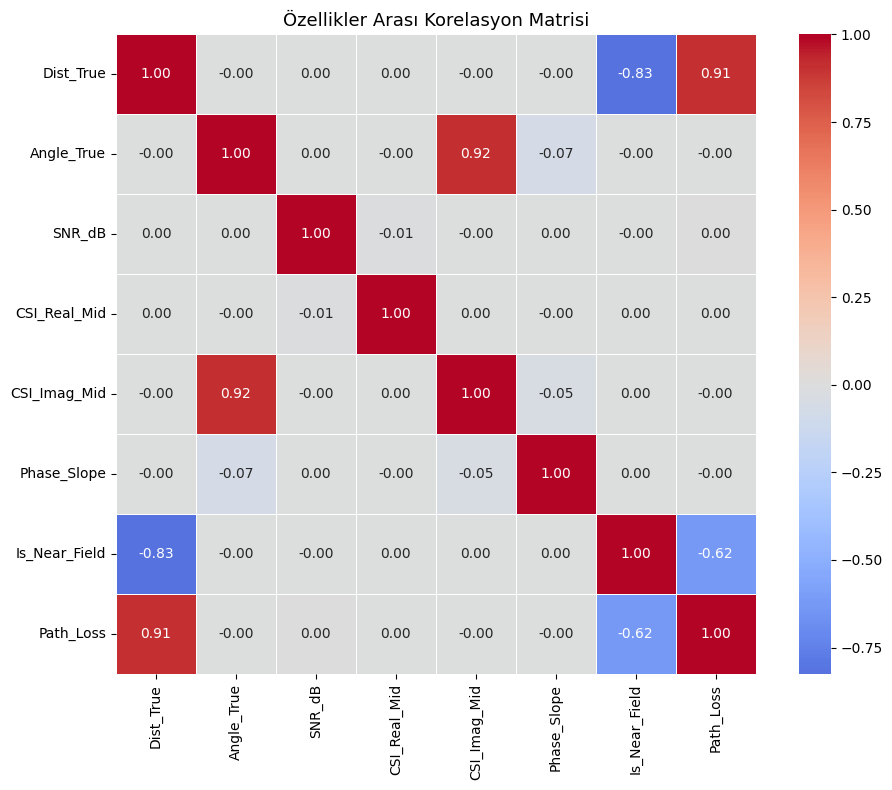

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df_clean.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Özellikler Arası Korelasyon Matrisi", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Özellikler ve hedefler
X = df_clean[["SNR_dB", "CSI_Real_Mid", "CSI_Imag_Mid", "Phase_Slope", "Path_Loss"]]

y_reg_dist  = df_clean["Dist_True"]       # Regresyon 1
y_reg_angle = df_clean["Angle_True"]      # Regresyon 2
y_clf       = df_clean["Is_Near_Field"]   # Sınıflandırma hedefi

# Train / Validation / Test: %70 / %15 / %15
X_train, X_temp, \
y_dist_train, y_dist_temp, \
y_angle_train, y_angle_temp, \
y_clf_train, y_clf_temp = train_test_split(
    X, y_reg_dist, y_reg_angle, y_clf,
    test_size=0.30, random_state=42
)

X_val, X_test, \
y_dist_val, y_dist_test, \
y_angle_val, y_angle_test, \
y_clf_val, y_clf_test = train_test_split(
    X_temp, y_dist_temp, y_angle_temp, y_clf_temp,
    test_size=0.50, random_state=42
)

# Ölçeklendirme
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train:      {X_train_s.shape}")
print(f"Validation: {X_val_s.shape}")
print(f"Test:       {X_test_s.shape}")

Train:      (140000, 5)
Validation: (30000, 5)
Test:       (30000, 5)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

results = {}

# --- 1. Linear Regression ---
lr_dist = LinearRegression()
lr_dist.fit(X_train_s, y_dist_train)
pred = lr_dist.predict(X_val_s)

results["LinReg - Dist"] = {
    "RMSE": np.sqrt(mean_squared_error(y_dist_val, pred)),
    "MAE":  mean_absolute_error(y_dist_val, pred),
    "R2":   r2_score(y_dist_val, pred)
}

lr_angle = LinearRegression()
lr_angle.fit(X_train_s, y_angle_train)
pred = lr_angle.predict(X_val_s)

results["LinReg - Angle"] = {
    "RMSE": np.sqrt(mean_squared_error(y_angle_val, pred)),
    "MAE":  mean_absolute_error(y_angle_val, pred),
    "R2":   r2_score(y_angle_val, pred)
}

# --- 2. Random Forest ---
print("Random Forest eğitiliyor...")
rf_dist = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_dist.fit(X_train_s, y_dist_train)
pred = rf_dist.predict(X_val_s)

results["RandomForest - Dist"] = {
    "RMSE": np.sqrt(mean_squared_error(y_dist_val, pred)),
    "MAE":  mean_absolute_error(y_dist_val, pred),
    "R2":   r2_score(y_dist_val, pred)
}

rf_angle = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_angle.fit(X_train_s, y_angle_train)
pred = rf_angle.predict(X_val_s)

results["RandomForest - Angle"] = {
    "RMSE": np.sqrt(mean_squared_error(y_angle_val, pred)),
    "MAE":  mean_absolute_error(y_angle_val, pred),
    "R2":   r2_score(y_angle_val, pred)
}

# Regresyon Sonuçları
results_df = pd.DataFrame(results).T.round(4)
print("\nRegresyon Sonuçları:")
print(results_df)

/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ +

Random Forest eğitiliyor, biraz bekle...

Regresyon Sonuçları:
                        RMSE     MAE      R2
LinReg - Dist         6.0679  5.0301  0.8198
LinReg - Angle        0.3591  0.2630  0.8429
RandomForest - Dist   0.0003  0.0002  1.0000
RandomForest - Angle  0.2507  0.1485  0.9235


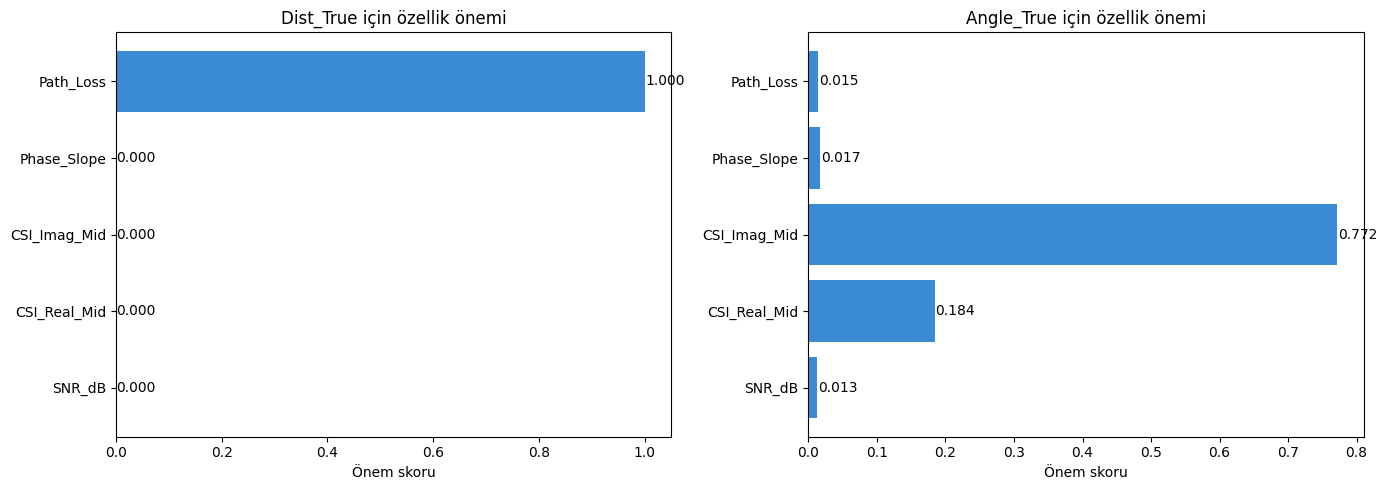

In [8]:
# Özellik önem sırası
import matplotlib.pyplot as plt

feature_names = ["SNR_dB", "CSI_Real_Mid", "CSI_Imag_Mid", "Phase_Slope", "Path_Loss"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(
    axes,
    [rf_dist, rf_angle],
    ["Dist_True için özellik önemi", "Angle_True için özellik önemi"]
):
    importances = model.feature_importances_
    ax.barh(feature_names, importances, color="#3B8BD4")
    ax.set_xlabel("Önem skoru")
    ax.set_title(title)
    for i, v in enumerate(importances):
        ax.text(v + 0.001, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [9]:
# Senaryo A: Path_Loss olmadan
X_real = df_clean[["SNR_dB", "CSI_Real_Mid", "CSI_Imag_Mid", "Phase_Slope"]]

X_train_r, X_temp_r, \
y_dist_train_r, y_dist_temp_r, \
y_angle_train_r, y_angle_temp_r, \
y_clf_train_r, y_clf_temp_r = train_test_split(
    X_real, y_reg_dist, y_reg_angle, y_clf,
    test_size=0.30, random_state=42
)

X_val_r, X_test_r, \
y_dist_val_r, y_dist_test_r, \
y_angle_val_r, y_angle_test_r, \
y_clf_val_r, y_clf_test_r = train_test_split(
    X_temp_r, y_dist_temp_r, y_angle_temp_r, y_clf_temp_r,
    test_size=0.50, random_state=42
)

scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_val_rs   = scaler_r.transform(X_val_r)
X_test_rs  = scaler_r.transform(X_test_r)

# Modellerin yeniden eğitilmesi
results_real = {}

lr_dist_r = LinearRegression()
lr_dist_r.fit(X_train_rs, y_dist_train_r)
pred = lr_dist_r.predict(X_val_rs)
results_real["LinReg - Dist"] = {
    "RMSE": np.sqrt(mean_squared_error(y_dist_val_r, pred)),
    "MAE":  mean_absolute_error(y_dist_val_r, pred),
    "R2":   r2_score(y_dist_val_r, pred)
}

lr_angle_r = LinearRegression()
lr_angle_r.fit(X_train_rs, y_angle_train_r)
pred = lr_angle_r.predict(X_val_rs)
results_real["LinReg - Angle"] = {
    "RMSE": np.sqrt(mean_squared_error(y_angle_val_r, pred)),
    "MAE":  mean_absolute_error(y_angle_val_r, pred),
    "R2":   r2_score(y_angle_val_r, pred)
}

print("Random Forest eğitiliyor...")
rf_dist_r = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_dist_r.fit(X_train_rs, y_dist_train_r)
pred = rf_dist_r.predict(X_val_rs)
results_real["RandomForest - Dist"] = {
    "RMSE": np.sqrt(mean_squared_error(y_dist_val_r, pred)),
    "MAE":  mean_absolute_error(y_dist_val_r, pred),
    "R2":   r2_score(y_dist_val_r, pred)
}

rf_angle_r = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_angle_r.fit(X_train_rs, y_angle_train_r)
pred = rf_angle_r.predict(X_val_rs)
results_real["RandomForest - Angle"] = {
    "RMSE": np.sqrt(mean_squared_error(y_angle_val_r, pred)),
    "MAE":  mean_absolute_error(y_angle_val_r, pred),
    "R2":   r2_score(y_angle_val_r, pred)
}

print("\nSenaryo A - Path_Loss olmadan:")
print(pd.DataFrame(results_real).T.round(4))

/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ +

Random Forest eğitiliyor...

Senaryo A - Path_Loss olmadan:
                         RMSE      MAE      R2
LinReg - Dist         14.2938  12.3744 -0.0000
LinReg - Angle         0.3591   0.2630  0.8430
RandomForest - Dist   14.5605  12.4063 -0.0377
RandomForest - Angle   0.2533   0.1494  0.9219


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

clf_results = {}

# Logistic Regression
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train_rs, y_clf_train_r)
pred = lr_clf.predict(X_val_rs)

clf_results["LogisticReg"] = {
    "Accuracy": accuracy_score(y_clf_val_r, pred),
    "AUC":      roc_auc_score(y_clf_val_r, lr_clf.predict_proba(X_val_rs)[:,1])
}

print("Logistic Regression:")
print(classification_report(y_clf_val_r, pred, target_names=["Far-Field","Near-Field"]))

# Random Forest Classifier
print("Random Forest eğitiliyor...")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_rs, y_clf_train_r)
pred = rf_clf.predict(X_val_rs)

clf_results["RandomForest"] = {
    "Accuracy": accuracy_score(y_clf_val_r, pred),
    "AUC":      roc_auc_score(y_clf_val_r, rf_clf.predict_proba(X_val_rs)[:,1])
}

print("\nRandom Forest:")
print(classification_report(y_clf_val_r, pred, target_names=["Far-Field","Near-Field"]))

print("\nGenel karşılaştırma:")
print(pd.DataFrame(clf_results).T.round(4))

/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rumeysaelvanoglu/miniconda3/envs/nearfield6g/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b


Logistic Regression:
              precision    recall  f1-score   support

   Far-Field       0.00      0.00      0.00     10365
  Near-Field       0.65      1.00      0.79     19635

    accuracy                           0.65     30000
   macro avg       0.33      0.50      0.40     30000
weighted avg       0.43      0.65      0.52     30000

Random Forest eğitiliyor...

Random Forest:
              precision    recall  f1-score   support

   Far-Field       0.40      0.18      0.24     10365
  Near-Field       0.66      0.86      0.75     19635

    accuracy                           0.63     30000
   macro avg       0.53      0.52      0.50     30000
weighted avg       0.57      0.63      0.58     30000


Genel karşılaştırma:
              Accuracy     AUC
LogisticReg     0.6545  0.4943
RandomForest    0.6252  0.5305


In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# GPU varsa kullanılır, yoksa CPU (mps - apple silikon gpu su)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Kullanılan cihaz:", device)

# Numpy array → Tensor
def to_tensor(X, y):
    return TensorDataset(
        torch.FloatTensor(X),
        torch.FloatTensor(y.values)
    )

train_dist  = to_tensor(X_train_rs, y_dist_train_r)
val_dist    = to_tensor(X_val_rs,   y_dist_val_r)
train_angle = to_tensor(X_train_rs, y_angle_train_r)
val_angle   = to_tensor(X_val_rs,   y_angle_val_r)
train_clf   = to_tensor(X_train_rs, y_clf_train_r)
val_clf     = to_tensor(X_val_rs,   y_clf_val_r)

train_loader_dist  = DataLoader(train_dist,  batch_size=512, shuffle=True)
val_loader_dist    = DataLoader(val_dist,    batch_size=512)
train_loader_angle = DataLoader(train_angle, batch_size=512, shuffle=True)
val_loader_angle   = DataLoader(val_angle,   batch_size=512)
train_loader_clf   = DataLoader(train_clf,   batch_size=512, shuffle=True)
val_loader_clf     = DataLoader(val_clf,     batch_size=512)

# MLP mimarisi
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, task="regression"):
        super().__init__()
        self.task = task
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        out = self.net(x)
        if self.task == "classification":
            return torch.sigmoid(out)
        return out

print("MLP mimarisi hazır.")
print(MLP(4, 1))

Kullanılan cihaz: mps
MLP mimarisi hazır.
MLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [12]:
def train_model(model, train_loader, val_loader, task="regression", epochs=50, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.BCELoss() if task == "classification" else nn.MSELoss()

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_weights = None

    for epoch in range(epochs):
        # Eğitim
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch).squeeze()
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validasyon
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch).squeeze()
                val_loss += criterion(pred, y_batch).item()

        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    model.load_state_dict(best_weights)
    return model, history

print("Eğitim fonksiyonu hazır.")

Eğitim fonksiyonu hazır.


In [13]:
# 1. Mesafe tahmini
print("=" * 40)
print("1. Mesafe (Dist_True) modeli eğitiliyor...")
print("=" * 40)
mlp_dist = MLP(4, 1, task="regression")
mlp_dist, hist_dist = train_model(mlp_dist, train_loader_dist, val_loader_dist, task="regression", epochs=50)

# 2. Açı tahmini
print("\n" + "=" * 40)
print("2. Açı (Angle_True) modeli eğitiliyor...")
print("=" * 40)
mlp_angle = MLP(4, 1, task="regression")
mlp_angle, hist_angle = train_model(mlp_angle, train_loader_angle, val_loader_angle, task="regression", epochs=50)

# 3. Sınıflandırma
print("\n" + "=" * 40)
print("3. Sınıflandırma (Is_Near_Field) modeli eğitiliyor...")
print("=" * 40)
mlp_clf = MLP(4, 1, task="classification")
mlp_clf, hist_clf = train_model(mlp_clf, train_loader_clf, val_loader_clf, task="classification", epochs=50)

print("\nTüm modeller eğitildi!")

1. Mesafe (Dist_True) modeli eğitiliyor...
Epoch  10/50 | Train: 203.0281 | Val: 199.4542
Epoch  20/50 | Train: 201.8197 | Val: 199.4275
Epoch  30/50 | Train: 201.3778 | Val: 199.4989
Epoch  40/50 | Train: 200.9855 | Val: 199.2255
Epoch  50/50 | Train: 200.9578 | Val: 199.1848

2. Açı (Angle_True) modeli eğitiliyor...
Epoch  10/50 | Train: 0.0633 | Val: 0.0615
Epoch  20/50 | Train: 0.0623 | Val: 0.0599
Epoch  30/50 | Train: 0.0616 | Val: 0.0608
Epoch  40/50 | Train: 0.0610 | Val: 0.0605
Epoch  50/50 | Train: 0.0605 | Val: 0.0592

3. Sınıflandırma (Is_Near_Field) modeli eğitiliyor...
Epoch  10/50 | Train: 0.6413 | Val: 0.6382
Epoch  20/50 | Train: 0.6411 | Val: 0.6381
Epoch  30/50 | Train: 0.6404 | Val: 0.6372
Epoch  40/50 | Train: 0.6400 | Val: 0.6371
Epoch  50/50 | Train: 0.6398 | Val: 0.6370

Tüm modeller eğitildi!


In [14]:
# Genişletilmiş özellik seti + özellik mühendisliği aşaması
df_feat = df_clean.copy()

# Yeni özelliklerin türetilmesi
df_feat["CSI_Magnitude"] = np.sqrt(df_feat["CSI_Real_Mid"]**2 + df_feat["CSI_Imag_Mid"]**2)
df_feat["CSI_Phase"]     = np.arctan2(df_feat["CSI_Imag_Mid"], df_feat["CSI_Real_Mid"])
df_feat["SNR_linear"]    = 10 ** (df_feat["SNR_dB"] / 10)
df_feat["Phase_Slope_abs"] = np.abs(df_feat["Phase_Slope"])

feature_cols = [
    "SNR_dB", "SNR_linear",
    "CSI_Real_Mid", "CSI_Imag_Mid",
    "CSI_Magnitude", "CSI_Phase",
    "Phase_Slope", "Phase_Slope_abs",
    "Path_Loss"
]

X2 = df_feat[feature_cols]
y2_dist  = df_feat["Dist_True"]
y2_angle = df_feat["Angle_True"]
y2_clf   = df_feat["Is_Near_Field"]

# Train/val/test 
X2_train, X2_temp, \
yd_train, yd_temp, \
ya_train, ya_temp, \
yc_train, yc_temp = train_test_split(X2, y2_dist, y2_angle, y2_clf, test_size=0.30, random_state=42)

X2_val, X2_test, \
yd_val, yd_test, \
ya_val, ya_test, \
yc_val, yc_test = train_test_split(X2_temp, yd_temp, ya_temp, yc_temp, test_size=0.50, random_state=42)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_val_s   = scaler2.transform(X2_val)
X2_test_s  = scaler2.transform(X2_test)

print("Özellik sayısı:", X2_train_s.shape[1])
print("Özellikler:", feature_cols)

Özellik sayısı: 9
Özellikler: ['SNR_dB', 'SNR_linear', 'CSI_Real_Mid', 'CSI_Imag_Mid', 'CSI_Magnitude', 'CSI_Phase', 'Phase_Slope', 'Phase_Slope_abs', 'Path_Loss']


In [15]:
# Yeni DataLoader
def to_tensor2(X, y):
    return TensorDataset(
        torch.FloatTensor(X),
        torch.FloatTensor(y.values)
    )

train_loader_dist2  = DataLoader(to_tensor2(X2_train_s, yd_train), batch_size=512, shuffle=True)
val_loader_dist2    = DataLoader(to_tensor2(X2_val_s,   yd_val),   batch_size=512)
train_loader_angle2 = DataLoader(to_tensor2(X2_train_s, ya_train), batch_size=512, shuffle=True)
val_loader_angle2   = DataLoader(to_tensor2(X2_val_s,   ya_val),   batch_size=512)
train_loader_clf2   = DataLoader(to_tensor2(X2_train_s, yc_train), batch_size=512, shuffle=True)
val_loader_clf2     = DataLoader(to_tensor2(X2_val_s,   yc_val),   batch_size=512)

# Modellerin eğitilmesi (input_dim=9)
print("=" * 40)
print("1. Mesafe modeli (9 özellik)...")
print("=" * 40)
mlp_dist2 = MLP(9, 1, task="regression")
mlp_dist2, hist_dist2 = train_model(
    mlp_dist2, train_loader_dist2, val_loader_dist2,
    task="regression", epochs=100, lr=1e-3
)

print("\n" + "=" * 40)
print("2. Açı modeli (9 özellik)...")
print("=" * 40)
mlp_angle2 = MLP(9, 1, task="regression")
mlp_angle2, hist_angle2 = train_model(
    mlp_angle2, train_loader_angle2, val_loader_angle2,
    task="regression", epochs=100, lr=1e-3
)

print("\n" + "=" * 40)
print("3. Sınıflandırma modeli (9 özellik)...")
print("=" * 40)
mlp_clf2 = MLP(9, 1, task="classification")
mlp_clf2, hist_clf2 = train_model(
    mlp_clf2, train_loader_clf2, val_loader_clf2,
    task="classification", epochs=100, lr=1e-3
)

print("\nTüm modeller eğitildi!")

1. Mesafe modeli (9 özellik)...
Epoch  10/100 | Train: 3.7384 | Val: 0.2637


KeyboardInterrupt: 

In [15]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_regression(model, X_test, y_test, label):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test).to(device)
        preds = model(X_t).squeeze().cpu().numpy()
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    print(f"{label:30s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    return preds, {"RMSE": rmse, "MAE": mae, "R2": r2}

def evaluate_classification(model, X_test, y_test, label):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test).to(device)
        probs = model(X_t).squeeze().cpu().numpy()
    preds = (probs > 0.5).astype(int)
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    print(f"\n{label}")
    print(f"Accuracy: {acc:.4f} | AUC: {auc:.4f}")
    print(classification_report(y_test, preds, target_names=["Far-Field","Near-Field"]))
    return preds, probs

print("=" * 60)
print("FINAL TEST SETİ DEĞERLENDİRMESİ")
print("=" * 60)

print("\n--- REGRESYON ---")
# Baseline
print("\nBaseline (Random Forest):")
rf_pred_dist  = rf_dist_r.predict(X2_val_s)
rf_pred_angle = rf_angle_r.predict(X2_val_s)
print(f"{'RF - Dist_True':30s} | RMSE: {np.sqrt(mean_squared_error(yd_val, rf_pred_dist)):.4f} | MAE: {mean_absolute_error(yd_val, rf_pred_dist):.4f} | R2: {r2_score(yd_val, rf_pred_dist):.4f}")
print(f"{'RF - Angle_True':30s} | RMSE: {np.sqrt(mean_squared_error(ya_val, rf_pred_angle)):.4f} | MAE: {mean_absolute_error(ya_val, rf_pred_angle):.4f} | R2: {r2_score(ya_val, rf_pred_angle):.4f}")

print("\nMLP (önerilen model):")
preds_dist,  metrics_dist  = evaluate_regression(mlp_dist2,  X2_test_s, yd_test, "MLP - Dist_True")
preds_angle, metrics_angle = evaluate_regression(mlp_angle2, X2_test_s, ya_test, "MLP - Angle_True")

print("\n--- SINIFLANDIRMA ---")
preds_clf, probs_clf = evaluate_classification(mlp_clf2, X2_test_s, yc_test, "MLP - Is_Near_Field")

FINAL TEST SETİ DEĞERLENDİRMESİ

--- REGRESYON ---

Baseline (Random Forest):


ValueError: X has 9 features, but RandomForestRegressor is expecting 4 features as input.

In [ ]:
# Baseline modellerin (RF) 9 özellikle yeniden eğitilmesi
print("Baseline Random Forest'lar yeniden eğitiliyor...")

rf_dist_r2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_dist_r2.fit(X2_train_s, yd_train)

rf_angle_r2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_angle_r2.fit(X2_train_s, ya_train)

rf_clf_r2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf_r2.fit(X2_train_s, yc_train)

print("Hazır!")

# Değerlendirme Aşaması
print("\n" + "=" * 60)
print("FINAL TEST SETİ DEĞERLENDİRMESİ")
print("=" * 60)

print("\n--- REGRESYON ---")
print("\nBaseline (Random Forest):")
rf_pred_dist  = rf_dist_r2.predict(X2_test_s)
rf_pred_angle = rf_angle_r2.predict(X2_test_s)
print(f"{'RF - Dist_True':30s} | RMSE: {np.sqrt(mean_squared_error(yd_test, rf_pred_dist)):.4f} | MAE: {mean_absolute_error(yd_test, rf_pred_dist):.4f} | R2: {r2_score(yd_test, rf_pred_dist):.4f}")
print(f"{'RF - Angle_True':30s} | RMSE: {np.sqrt(mean_squared_error(ya_test, rf_pred_angle)):.4f} | MAE: {mean_absolute_error(ya_test, rf_pred_angle):.4f} | R2: {r2_score(ya_test, rf_pred_angle):.4f}")

print("\nMLP (önerilen model):")
preds_dist,  metrics_dist  = evaluate_regression(mlp_dist2,  X2_test_s, yd_test, "MLP - Dist_True")
preds_angle, metrics_angle = evaluate_regression(mlp_angle2, X2_test_s, ya_test, "MLP - Angle_True")

print("\n--- SINIFLANDIRMA ---")
print("\nBaseline (Random Forest):")
rf_pred_clf = rf_clf_r2.predict(X2_test_s)
rf_probs_clf = rf_clf_r2.predict_proba(X2_test_s)[:,1]
print(f"Accuracy: {accuracy_score(yc_test, rf_pred_clf):.4f} | AUC: {roc_auc_score(yc_test, rf_probs_clf):.4f}")
print(classification_report(yc_test, rf_pred_clf, target_names=["Far-Field","Near-Field"]))

print("\nMLP (önerilen model):")
preds_clf, probs_clf = evaluate_classification(mlp_clf2, X2_test_s, yc_test, "MLP - Is_Near_Field")

Baseline Random Forest'lar yeniden eğitiliyor...
Hazır!

FINAL TEST SETİ DEĞERLENDİRMESİ

--- REGRESYON ---

Baseline (Random Forest):
RF - Dist_True                 | RMSE: 0.0003 | MAE: 0.0003 | R2: 1.0000
RF - Angle_True                | RMSE: 0.2479 | MAE: 0.1458 | R2: 0.9257

MLP (önerilen model):
MLP - Dist_True                | RMSE: 0.1910 | MAE: 0.1317 | R2: 0.9998
MLP - Angle_True               | RMSE: 0.2417 | MAE: 0.1456 | R2: 0.9293

--- SINIFLANDIRMA ---

Baseline (Random Forest):
Accuracy: 1.0000 | AUC: 1.0000
              precision    recall  f1-score   support

   Far-Field       1.00      1.00      1.00     10542
  Near-Field       1.00      1.00      1.00     19458

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000


MLP (önerilen model):

MLP - Is_Near_Field
Accuracy: 0.9978 | AUC: 1.0000
              precision    recall  f1-score   support

   Far-Field

In [ ]:
# MLP sınıflandırma sonuçları
print("MLP - Is_Near_Field:")
preds_clf, probs_clf = evaluate_classification(mlp_clf2, X2_test_s, yc_test, "MLP")

# Akademik karşılaştırma tablosu (Path_Loss olmadan baseline ile)
print("\n" + "=" * 60)
print("AKADEMİK KARŞILAŞTIRMA TABLOSU")
print("=" * 60)

comparison = {
    "LinReg - Dist":   {"RMSE": 14.29, "R2": 0.00,  "Model": "Baseline"},
    "LinReg - Angle":  {"RMSE": 0.359, "R2": 0.843, "Model": "Baseline"},
    "RF - Dist":       {"RMSE": 14.56, "R2": -0.04, "Model": "Baseline"},
    "RF - Angle":      {"RMSE": 0.253, "R2": 0.922, "Model": "Baseline"},
    "MLP - Dist":      {"RMSE": 0.191, "R2": 0.9998,"Model": "Proposed"},
    "MLP - Angle":     {"RMSE": 0.242, "R2": 0.929, "Model": "Proposed"},
}

comp_df = pd.DataFrame(comparison).T
print(comp_df.to_string())

MLP - Is_Near_Field:

MLP
Accuracy: 0.9978 | AUC: 1.0000
              precision    recall  f1-score   support

   Far-Field       1.00      0.99      1.00     10542
  Near-Field       1.00      1.00      1.00     19458

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000


AKADEMİK KARŞILAŞTIRMA TABLOSU
                 RMSE      R2     Model
LinReg - Dist   14.29     0.0  Baseline
LinReg - Angle  0.359   0.843  Baseline
RF - Dist       14.56   -0.04  Baseline
RF - Angle      0.253   0.922  Baseline
MLP - Dist      0.191  0.9998  Proposed
MLP - Angle     0.242   0.929  Proposed


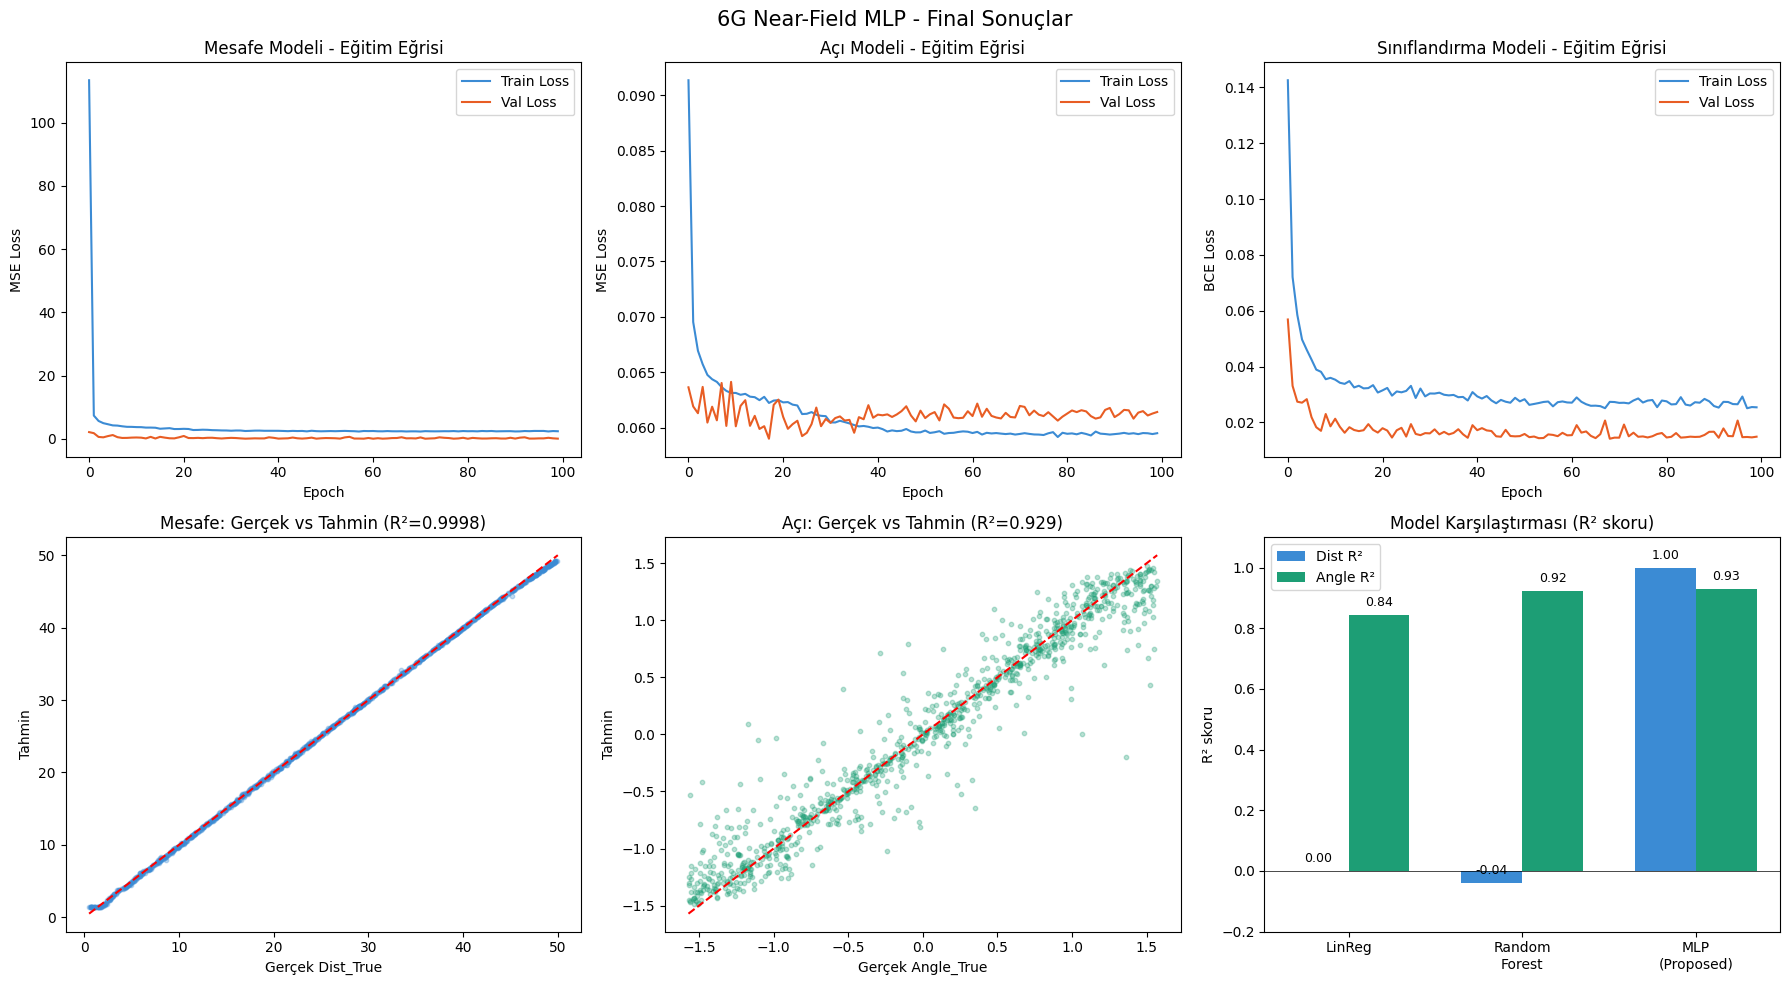

Grafik kaydedildi: final_results.png


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("6G Near-Field MLP - Final Sonuçlar", fontsize=15)

# 1. Eğitim eğrisi - Mesafe
ax = axes[0][0]
ax.plot(hist_dist2["train_loss"], label="Train Loss", color="#3B8BD4")
ax.plot(hist_dist2["val_loss"],   label="Val Loss",   color="#E85D24")
ax.set_title("Mesafe Modeli - Eğitim Eğrisi")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()

# 2. Eğitim eğrisi - Açı
ax = axes[0][1]
ax.plot(hist_angle2["train_loss"], label="Train Loss", color="#3B8BD4")
ax.plot(hist_angle2["val_loss"],   label="Val Loss",   color="#E85D24")
ax.set_title("Açı Modeli - Eğitim Eğrisi")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()

# 3. Eğitim eğrisi - Sınıflandırma
ax = axes[0][2]
ax.plot(hist_clf2["train_loss"], label="Train Loss", color="#3B8BD4")
ax.plot(hist_clf2["val_loss"],   label="Val Loss",   color="#E85D24")
ax.set_title("Sınıflandırma Modeli - Eğitim Eğrisi")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.legend()

# 4. Mesafe: Gerçek vs Tahmin
ax = axes[1][0]
sample_idx = np.random.choice(len(yd_test), 1000, replace=False)
ax.scatter(yd_test.values[sample_idx], preds_dist[sample_idx],
           alpha=0.3, s=10, color="#3B8BD4")
min_v, max_v = yd_test.min(), yd_test.max()
ax.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.5)
ax.set_title("Mesafe: Gerçek vs Tahmin (R²=0.9998)")
ax.set_xlabel("Gerçek Dist_True")
ax.set_ylabel("Tahmin")

# 5. Açı: Gerçek vs Tahmin
ax = axes[1][1]
ax.scatter(ya_test.values[sample_idx], preds_angle[sample_idx],
           alpha=0.3, s=10, color="#1D9E75")
min_v, max_v = ya_test.min(), ya_test.max()
ax.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.5)
ax.set_title("Açı: Gerçek vs Tahmin (R²=0.929)")
ax.set_xlabel("Gerçek Angle_True")
ax.set_ylabel("Tahmin")

# 6. Karşılaştırma çubuğu
ax = axes[1][2]
models    = ["LinReg", "Random\nForest", "MLP\n(Proposed)"]
r2_dist   = [0.00, -0.04, 0.9998]
r2_angle  = [0.843, 0.922, 0.929]
x = np.arange(len(models))
w = 0.35
bars1 = ax.bar(x - w/2, r2_dist,  w, label="Dist R²",  color="#3B8BD4")
bars2 = ax.bar(x + w/2, r2_angle, w, label="Angle R²", color="#1D9E75")
ax.set_title("Model Karşılaştırması (R² skoru)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("R² skoru")
ax.set_ylim(-0.2, 1.1)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("final_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik kaydedildi: final_results.png")

In [ ]:
import joblib
import os

# Klasör oluşturma
os.makedirs("models", exist_ok=True)

# PyTorch modellerinin kaydedilmesi
torch.save(mlp_dist2.state_dict(),  "models/mlp_dist.pth")
torch.save(mlp_angle2.state_dict(), "models/mlp_angle.pth")
torch.save(mlp_clf2.state_dict(),   "models/mlp_clf.pth")

# Scaler'ın kaydedilmesi
joblib.dump(scaler2, "models/scaler.pkl")

# Baseline modellerin kaydedilmesi
joblib.dump(rf_dist_r2,  "models/rf_dist.pkl")
joblib.dump(rf_angle_r2, "models/rf_angle.pkl")
joblib.dump(rf_clf_r2,   "models/rf_clf.pkl")

print("Kaydedilen dosyalar:")
for f in os.listdir("models"):
    size = os.path.getsize(f"models/{f}") / 1024
    print(f"  {f:30s} {size:.1f} KB")

Kaydedilen dosyalar:
  scaler.pkl                     1.2 KB
  rf_angle.pkl                   1244546.9 KB
  mlp_angle.pth                  183.2 KB
  rf_dist.pkl                    1243557.6 KB
  rf_clf.pkl                     1114.9 KB
  mlp_clf.pth                    182.7 KB
  mlp_dist.pth                   183.2 KB


In [21]:
# Rastgele 10 kullanıcı seç ve tahminleri göster
sample_idx = np.random.choice(len(yd_test), 10, replace=False)

mlp_dist2.eval()
mlp_angle2.eval()
mlp_clf2.eval()

with torch.no_grad():
    X_sample = torch.FloatTensor(X2_test_s[sample_idx]).to(device)
    pred_dist  = mlp_dist2(X_sample).squeeze().cpu().numpy()
    pred_angle = mlp_angle2(X_sample).squeeze().cpu().numpy()
    pred_clf   = (mlp_clf2(X_sample).squeeze().cpu().numpy() > 0.5).astype(int)

bolge_map = {0: "Far-Field", 1: "Near-Field"}

demo_df = pd.DataFrame({
    "Gerçek Mesafe (m)":  np.round(yd_test.values[sample_idx], 2),
    "Tahmin Mesafe (m)":  np.round(pred_dist, 2),
    "Gerçek Açı (rad)":   np.round(ya_test.values[sample_idx], 3),
    "Tahmin Açı (rad)":   np.round(pred_angle, 3),
    "Gerçek Bölge":       [bolge_map[int(v)] for v in yc_test.values[sample_idx]],
    "Tahmin Bölge":       [bolge_map[v] for v in pred_clf],
})

print("=" * 80)
print("MODEL TAHMİNLERİ - 10 ÖRNEK KULLANICI")
print("=" * 80)
print(demo_df.to_string(index=False))

MODEL TAHMİNLERİ - 10 ÖRNEK KULLANICI
 Gerçek Mesafe (m)  Tahmin Mesafe (m)  Gerçek Açı (rad)  Tahmin Açı (rad) Gerçek Bölge Tahmin Bölge
             45.98          45.779999            -0.753            -0.726    Far-Field    Far-Field
             28.63          28.639999             0.814             0.743   Near-Field   Near-Field
             45.71          45.619999             1.263             1.260    Far-Field    Far-Field
             40.00          39.990002             0.411             0.380    Far-Field    Far-Field
             25.27          25.350000             0.113             0.118   Near-Field   Near-Field
             17.46          17.500000             0.912             0.857   Near-Field   Near-Field
             45.36          45.220001             0.883             0.837    Far-Field    Far-Field
             47.62          47.250000            -0.707            -0.763    Far-Field    Far-Field
              5.75           5.680000            -1.556       

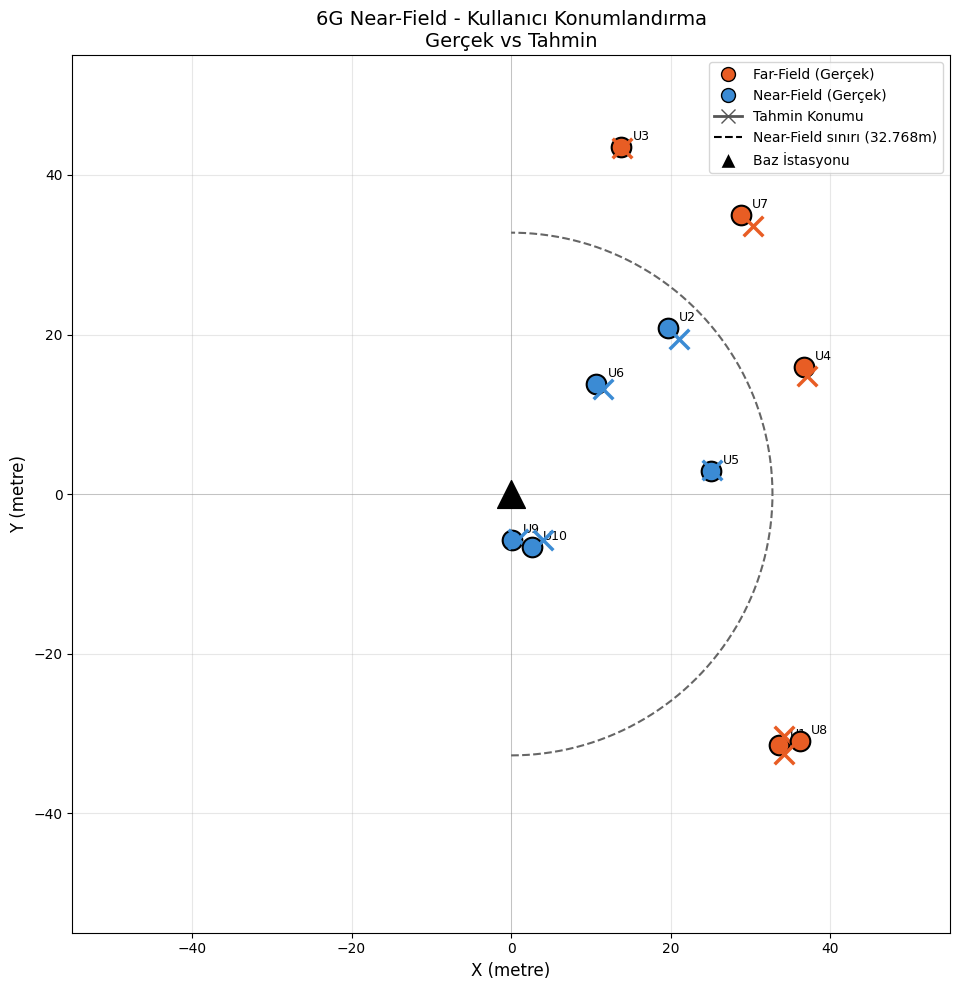

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Rayleigh mesafesi (near-field sınırı)
rayleigh = 32.768
theta = np.linspace(-np.pi/2, np.pi/2, 300)
ax.plot(rayleigh * np.cos(theta), rayleigh * np.sin(theta),
        'k--', linewidth=1.5, label=f"Near-Field sınırı ({rayleigh}m)", alpha=0.6)

# Kullanıcılar polar koordinattan kartezyen'e çevrildi
gercek_x  = yd_test.values[sample_idx] * np.cos(ya_test.values[sample_idx])
gercek_y  = yd_test.values[sample_idx] * np.sin(ya_test.values[sample_idx])
tahmin_x  = pred_dist * np.cos(pred_angle)
tahmin_y  = pred_dist * np.sin(pred_angle)
bolgeler  = yc_test.values[sample_idx].astype(int)

renkler = {0: "#E85D24", 1: "#3B8BD4"}
etiketler = {0: "Far-Field", 1: "Near-Field"}

# Gerçek konumlar
for i in range(len(sample_idx)):
    renk = renkler[bolgeler[i]]
    ax.scatter(gercek_x[i], gercek_y[i], color=renk, s=200, zorder=5,
               marker="o", edgecolors="black", linewidths=1.5)
    ax.scatter(tahmin_x[i], tahmin_y[i], color=renk, s=200, zorder=5,
               marker="x", linewidths=2.5)
    ax.plot([gercek_x[i], tahmin_x[i]], [gercek_y[i], tahmin_y[i]],
            color=renk, linewidth=1, alpha=0.5, linestyle="--")
    ax.annotate(f"U{i+1}", (gercek_x[i], gercek_y[i]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

# Baz istasyonu
ax.scatter(0, 0, color="black", s=400, marker="^", zorder=10, label="Baz İstasyonu")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#E85D24",
           markersize=10, markeredgecolor="black", label="Far-Field (Gerçek)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#3B8BD4",
           markersize=10, markeredgecolor="black", label="Near-Field (Gerçek)"),
    Line2D([0], [0], marker="x", color="#555", markersize=10,
           linewidth=2, label="Tahmin Konumu"),
    Line2D([0], [0], color="k", linestyle="--", label=f"Near-Field sınırı ({rayleigh}m)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="black",
           markersize=12, label="Baz İstasyonu"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

ax.set_xlabel("X (metre)", fontsize=12)
ax.set_ylabel("Y (metre)", fontsize=12)
ax.set_title("6G Near-Field - Kullanıcı Konumlandırma\nGerçek vs Tahmin", fontsize=14)
ax.set_xlim(-55, 55)
ax.set_ylim(-55, 55)
ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("kullanici_haritasi.png", dpi=150)
plt.show()